## Day 1 - Dataset Selection & Initial EDA

## Load the Dataset

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_excel(
    '../data/online_retail_II.xlsx',
    sheet_name='Year 2009-2010'
)

df2 = pd.read_excel(
    '../data/online_retail_II.xlsx',
    sheet_name='Year 2010-2011'
)

df = pd.concat([df1, df2], ignore_index=True)
print(df.shape)       # Should show ~1 million rows, 8 columns
print(df.dtypes)      # Check data types
print(df.head())      # First 5 rows

(1067371, 8)
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01

## Distribution Analysis

In [19]:
# How many rows and columns?
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Count unique customers, products, countries
print(f"Unique customers: {df['Customer ID'].nunique()}")
print(f"Unique products: {df['StockCode'].nunique()}")
print(f"Unique countries: {df['Country'].nunique()}")

# Date range
print(f"From: {df['InvoiceDate'].min()}")
print(f"To:   {df['InvoiceDate'].max()}")

# Top 10 countries by orders
print(df['Country'].value_counts().head(10))

# Distribution of Quantity and Price
df[['Quantity', 'Price']].describe()

Rows: 1067371, Columns: 8
Unique customers: 5942
Unique products: 5305
Unique countries: 43
From: 2009-12-01 07:45:00
To:   2011-12-09 12:50:00
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64


,Quantity,Price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
max,8.099500e+04,3.897000e+04


## Missing Values Analysis

In [20]:
# Count missing values in each column
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# You'll find: Customer ID has ~25% missing — important!

             Missing Count  Missing %
Description           4382   0.410541
Customer ID         243007  22.766873


## Correlation Heatmap

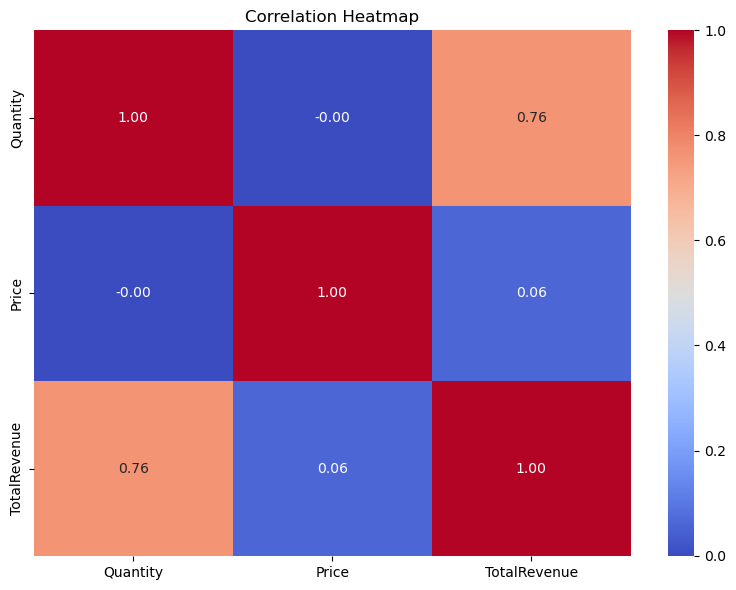

In [21]:
# Add a TotalRevenue column first
df['TotalRevenue'] = df['Quantity'] * df['Price']

# Correlation between numeric columns
corr = df[['Quantity', 'Price', 'TotalRevenue']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('Day1_correlation_heatmap.png')
plt.show()